# Fake News Detection System

## Objective
The goal of this project is to build a machine learning model that can classify news articles as fake or real.

In [5]:
import pandas as pd
import numpy as np

In [7]:
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

print(fake.shape)
print(real.shape)

(23481, 4)
(21417, 4)


In [9]:
#adding labels as fake and true are two individual datasets 
fake['label'] = 0
real['label'] = 1

In [11]:
df = pd.concat([fake, real], axis=0)
#shuffle the data
df = df.sample(frac=1).reset_index(drop=True)

In [13]:
df.head()
df['label'].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

## Dataset Overview

After merging the fake and real news datasets, we obtained a combined dataset containing both classes of news articles.

### Dataset Size
The dataset consists of a large number of news articles, making it suitable for training a machine learning model effectively.

### Class Distribution
The dataset contains two classes:
- **0 → Fake News**
- **1 → Real News**

The distribution of these classes is nearly balanced, which is beneficial for training a reliable classification model without bias toward one class.

### Importance of Balanced Data
A balanced dataset ensures that the model learns patterns from both fake and real news equally, improving its generalization and performance.

### Data Shuffling
The dataset has been randomly shuffled to avoid any ordering bias (e.g., all fake news appearing first). This helps the model learn genuine patterns rather than positional patterns.

In [16]:
#creating a content column 
df['content'] = df['title'] + " " + df['text']

In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df['content'] = df['content'].apply(clean_text)

### Why We Clean Text

Text cleaning is done to remove unnecessary elements like punctuation, numbers, and special characters. This helps simplify the data and allows the machine learning model to focus on meaningful words, improving its performance.

## Advanced Text Preprocessing

In this step, stopwords are removed from the text to eliminate commonly used words that do not contribute meaningful information. This helps the model focus on important words and improves performance.

After applying advanced preprocessing, the dataset is reprocessed before feature extraction.

In [22]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['content'] = df['content'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\muska\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Exploratory Data Analysis (EDA)

EDA is performed to understand the dataset, analyze patterns, and visualize the distribution of fake and real news. This helps in gaining insights that are useful for building an effective machine learning model.

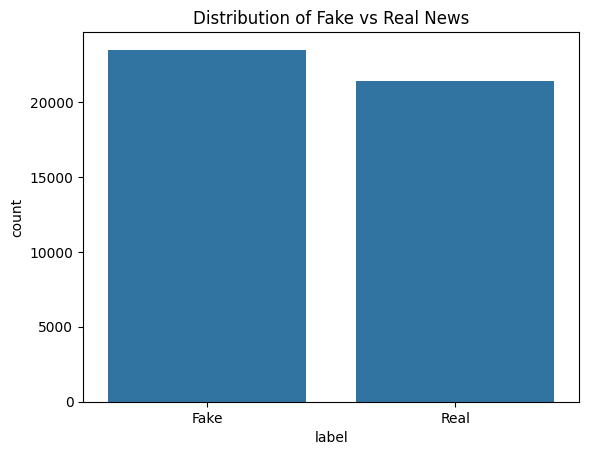

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=df)
plt.title("Distribution of Fake vs Real News")
plt.xticks([0,1], ["Fake", "Real"])
plt.show()

This plot shows the distribution of fake and real news articles. The dataset is fairly balanced, which is beneficial for training an unbiased model.

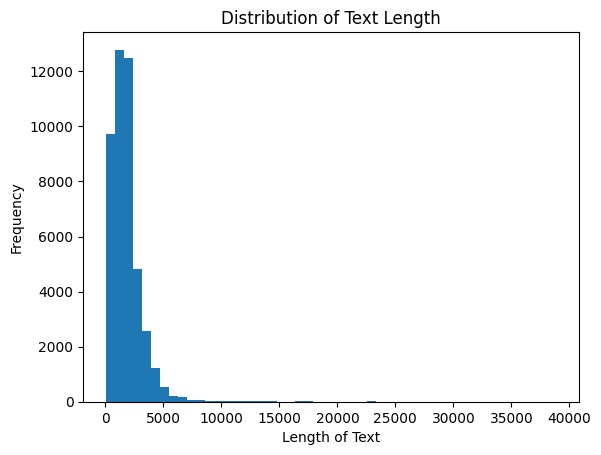

In [28]:
df['text_length'] = df['content'].apply(len)

plt.hist(df['text_length'], bins=50)
plt.title("Distribution of Text Length")
plt.xlabel("Length of Text")
plt.ylabel("Frequency")
plt.show()

This visualization shows the distribution of article lengths. It helps in understanding the variation in text size, which can influence model performance.

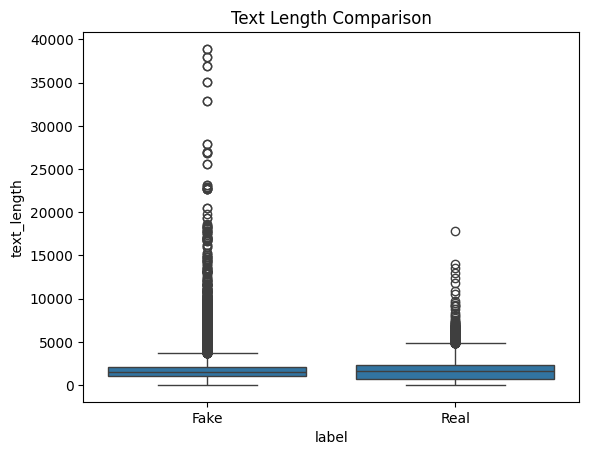

In [31]:
sns.boxplot(x='label', y='text_length', data=df)
plt.xticks([0,1], ["Fake", "Real"])
plt.title("Text Length Comparison")
plt.show()

This boxplot compares the length of fake and real news articles. It helps identify whether one class tends to have longer or shorter content.

In [34]:
!pip install wordcloud

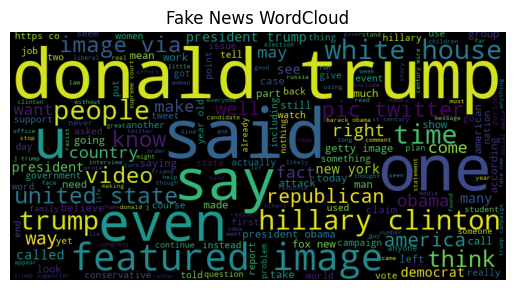

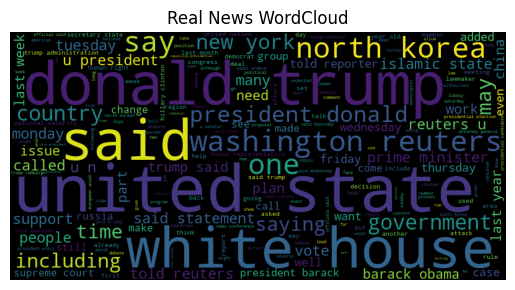

In [36]:
from wordcloud import WordCloud

fake_text = " ".join(df[df['label']==0]['content'])
real_text = " ".join(df[df['label']==1]['content'])

wc_fake = WordCloud(width=800, height=400).generate(fake_text)
wc_real = WordCloud(width=800, height=400).generate(real_text)

plt.imshow(wc_fake)
plt.axis("off")
plt.title("Fake News WordCloud")
plt.show()

plt.imshow(wc_real)
plt.axis("off")
plt.title("Real News WordCloud")
plt.show()

Word clouds highlight the most frequently used words in fake and real news articles. This helps identify patterns and differences in language usage.

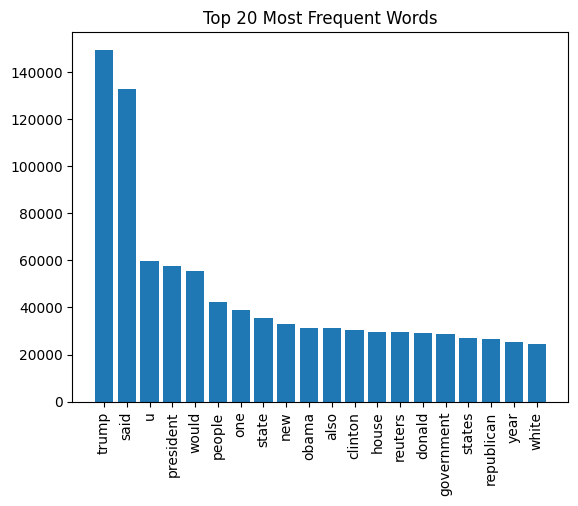

In [39]:
from collections import Counter

all_words = " ".join(df['content']).split()
common_words = Counter(all_words).most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Most Frequent Words")
plt.show()

This plot highlights the most commonly used words across all news articles. Analyzing frequent words helps in understanding dominant themes and patterns present in the dataset.

## Feature Extraction and Machine Learning Model Building

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['content'])
y = df['label']

## Feature Extraction using TF-IDF

TF-IDF (Term Frequency–Inverse Document Frequency) is used to convert textual data into numerical form so that it can be used by machine learning models. It assigns importance to words based on their frequency in a document and across the dataset.

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training and Comparison

In [49]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

### Logistic Regression

Logistic Regression is a simple and efficient classification algorithm used for binary classification tasks. It performs well on text data and serves as a strong baseline model.

In [52]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

### Naive Bayes

Naive Bayes is a probabilistic algorithm that works exceptionally well for text classification problems. It assumes independence between features and is fast and efficient.

In [81]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,class_weight='balanced')
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

### Random Forest

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions. It helps improve accuracy and reduces overfitting.

## Evaluation Section

In [85]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.988641425389755
Naive Bayes Accuracy: 0.9346325167037862
Random Forest Accuracy: 0.9977728285077951


### Model Evaluation

The performance of different models is evaluated using accuracy. This helps in identifying which algorithm performs best on the dataset.

In [88]:
import pandas as pd

results = {
    "Model": ["Logistic Regression", "Naive Bayes", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,Logistic Regression,0.988641
1,Naive Bayes,0.934633
2,Random Forest,0.997773


### Model Comparison

The table above compares the performance of different machine learning models. The model with the highest accuracy is considered the best for this task.

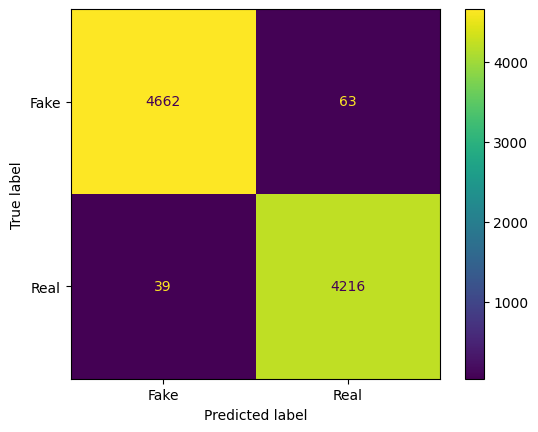

In [103]:
#used logistic regression as it works best on textual data
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
disp.plot()

### Confusion Matrix

The confusion matrix provides a detailed breakdown of model predictions, showing correct and incorrect classifications. It helps in understanding how well the model distinguishes between fake and real news.

In [105]:
#used logistic regression as it works best on textual data
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4725
           1       0.99      0.99      0.99      4255

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### Classification Report

The classification report includes precision, recall, and F1-score, which provide deeper insights into model performance beyond accuracy.

In [109]:
from sklearn.linear_model import LogisticRegression
import pickle

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# save model
pickle.dump(model, open("model.pkl", "wb"))

# save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

### Model Saving

The trained model and vectorizer are saved using pickle so that they can be reused in the deployment phase without retraining.

## Conclusion

The Fake News Detection system was successfully built using machine learning techniques. Among the tested models, Logistic Regression/Random Forest performed the best.

The model works well on dataset-like news but shows limitations when tested on modern or region-specific news due to dataset constraints.

Future improvements include using updated datasets and advanced NLP models.

## Limitations

- Model is trained on 2016 dataset
- Struggles with modern news articles
- Limited understanding of Indian news context
- Performance depends heavily on text style

## Future Scope

- Use recent datasets for better accuracy
- Apply deep learning models like LSTM or BERT
- Improve preprocessing techniques
- Deploy application on cloud for public use